In [ ]:
# Installing Libraries

In [ ]:
!pip uninstall -y transformers torchvision torch torchaudio accelerate -q

!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
--index-url https://download.pytorch.org/whl/cu128

!pip install -q \
transformers==4.53.3 \
accelerate==1.8.1 \
datasets==4.0.0 \
evaluate==0.4.5 \
sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 37.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 70.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 65.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 726.9/726.9 MB 38.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 609.6/609.6 MB 66.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 65.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 95.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.4/260.4 MB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 MB 122.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 106.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 72.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 80.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

import torch
import evaluate

from datasets import Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

warnings.filterwarnings("ignore")

In [ ]:
# Random Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [ ]:
# Path to your MLM model
MLM_MODEL_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_MLM8"

In [ ]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MLM_MODEL_PATH)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
# Load MLM Model
mlm_model = AutoModelForMaskedLM.from_pretrained(
    MLM_MODEL_PATH
)

print("MLM Model Loaded Successfully")

MLM Model Loaded Successfully


In [ ]:
# Load and Merge Datasets
ENGLISH_PATH = "/content/English_train_data.csv"

HINDI_PATH = "/content/english_to_hindi.csv"

BENGALI_PATH = "/content/english_to_bengali.csv"

NONE_PATH = "/content/non_climate_none.csv"


In [ ]:
# Load CSV Files
english_df = pd.read_csv(ENGLISH_PATH)
hindi_df = pd.read_csv(HINDI_PATH)
bengali_df = pd.read_csv(BENGALI_PATH)
none_df = pd.read_csv(NONE_PATH)

print("English :", english_df.shape)
print("Hindi   :", hindi_df.shape)
print("Bengali :", bengali_df.shape)
print("NONE    :", none_df.shape)

English : (12771, 2)
Hindi   : (12771, 3)
Bengali : (12771, 3)
NONE    : (10000, 2)


In [ ]:
#Check column Names
print("English Columns :", english_df.columns.tolist())
print("Hindi Columns   :", hindi_df.columns.tolist())
print("Bengali Columns :", bengali_df.columns.tolist())
print("NONE Columns    :", none_df.columns.tolist())

English Columns : ['sentence', 'label']
Hindi Columns   : ['sentence', 'label', 'hindi']
Bengali Columns : ['sentence', 'label', 'bengali']
NONE Columns    : ['sentence', 'label']


In [ ]:
hindi = hindi_df[["hindi","label"]].copy()
hindi.columns = ["sentence","label"]

bengali = bengali_df[["bengali","label"]].copy()
bengali.columns = ["sentence","label"]

english = english_df[["sentence","label"]].copy()

none_df = none_df[["sentence","label"]].copy()

In [ ]:
#merge evrything together
train_df = pd.concat(
    [
        english,
        hindi,
        bengali,
        none_df
    ],
    ignore_index=True
)

print("Merged Dataset :", train_df.shape)

Merged Dataset : (48313, 2)


In [ ]:
# Remove empty rows
train_df.dropna(inplace=True)

train_df["sentence"] = train_df["sentence"].astype(str)

train_df = train_df[
    train_df["sentence"].str.strip() != ""
]

print(train_df.shape)

(48313, 2)


In [ ]:
# Remove Duplicate Sentences
before = len(train_df)

train_df.drop_duplicates(
    subset=["sentence"],
    inplace=True
)

after = len(train_df)

print("Duplicates Removed :", before-after)

Duplicates Removed : 448


In [ ]:
# Shuffle Dataset
train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
# Check Label Distribution
print(train_df["label"].value_counts())

label
NONE       22650
AGAINST    12610
FAVOR      12605
Name: count, dtype: int64


In [ ]:
# Save Dataset
SAVE_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv"

train_df.to_csv(
    SAVE_PATH,
    index=False
)

print("Saved Successfully")
print(SAVE_PATH)

Saved Successfully
/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv


In [ ]:
# Part 4: Label Encoding & Train- Test Split
# Load the Final Dataset
import pandas as pd

train_df = pd.read_csv(
    "/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv"
)

print(train_df.shape)
train_df.head()

(47865, 2)


,sentence,label
0,"बहरहाल, ग्लोबल वार्मिंग उन्माद के पीछे एक वास्...",AGAINST
1,: চীন খুব সদয়ভাবে ট্রাম্পকে ব্যাখ্যা করেছে যে...,FAVOR
2,उस पर रखें। इस सप्ताह पहले ऐसा ही कुछ सुना था....,NONE
3,আপনি কীভাবে আমাকে বলবেন যে জলবায়ু পরিবর্তন/গ্...,NONE
4,Maybe it's like climate change making all the ...,NONE


In [ ]:
# Check Labeled Distribution
print(train_df["label"].value_counts())

label
NONE       22650
AGAINST    12610
FAVOR      12605
Name: count, dtype: int64


In [ ]:
# Encode Labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["label"])

print(label_encoder.classes_)

['AGAINST' 'FAVOR' 'NONE']


In [ ]:
# Save Label Mapping
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'AGAINST': np.int64(0), 'FAVOR': np.int64(1), 'NONE': np.int64(2)}


In [ ]:
#Reverse mapping
id2label = {v:k for k,v in label_mapping.items()}

print(id2label)

{np.int64(0): 'AGAINST', np.int64(1): 'FAVOR', np.int64(2): 'NONE'}


In [ ]:
# Stratified Train-Test Split
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(

    train_df["sentence"],

    train_df["label"],

    test_size=0.2,

    random_state=42,

    stratify=train_df["label"]

)

In [ ]:
# Verify Sizes
print("Training Samples :", len(train_texts))
print("Validation Samples :", len(val_texts))

Training Samples : 38292
Validation Samples : 9573


In [ ]:
# Verify Class Balance
print(pd.Series(train_labels).value_counts())

print()

print(pd.Series(val_labels).value_counts())

label
2    18120
0    10088
1    10084
Name: count, dtype: int64

label
2    4530
0    2522
1    2521
Name: count, dtype: int64


In [ ]:
# Convert to Dataframes
train_df = pd.DataFrame({

    "sentence":train_texts,

    "label":train_labels

})

val_df = pd.DataFrame({

    "sentence":val_texts,

    "label":val_labels

})

train_df.reset_index(drop=True,inplace=True)
val_df.reset_index(drop=True,inplace=True)

In [ ]:
# Verify
train_df.head()

,sentence,label
0,ive never understood why apple does this they ...,2
1,इस बात का कोई सांख्यिकीय प्रमाण नहीं है कि ग्ल...,0
2,the bounce back between level 1 and 3 were gre...,2
3,मुझे नफ़रत है कि यह कितनी ठंड है। अब ग्लोबल वा...,2
4,building wealth involves developing good habit...,2


In [ ]:
# PART 5 : Tokenization + Hugging Face Dataset
# Imports
from datasets import Dataset
from transformers import DataCollatorWithPadding

In [ ]:
# Convert Pandas → Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['sentence', 'label'],
    num_rows: 38292
})
Dataset({
    features: ['sentence', 'label'],
    num_rows: 9573
})


In [ ]:
# Load Your MLM Tokenizer
from transformers import AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_MLM8"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
# Inspect Comments length
lengths = train_df["sentence"].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

print(lengths.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


count    38292.000000
mean        33.290034
std         28.672160
min          3.000000
25%         22.000000
50%         30.000000
75%         39.000000
max       1453.000000
Name: sentence, dtype: float64


In [ ]:
print(lengths.quantile(0.95))

57.0


In [ ]:
MAX_LEN = 57

In [ ]:
# Tokenization Function
MAX_LEN = 57

def tokenize(batch):

    return tokenizer(

        batch["sentence"],

        truncation=True,

        max_length=MAX_LEN,

        padding=False

    )

In [ ]:
# Tokenize Dataset
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/38292 [00:00<?, ? examples/s]

Map:   0%|          | 0/9573 [00:00<?, ? examples/s]

In [ ]:
# Remove sentence Column
train_dataset = train_dataset.remove_columns(["sentence"])

val_dataset = val_dataset.remove_columns(["sentence"])

In [ ]:
#Rename Labels
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

In [ ]:
# Set torch Format
train_dataset.set_format("torch")

val_dataset.set_format("torch")

In [ ]:
# Dynamic Padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
# Verify
train_dataset.set_format("pandas")
print(train_dataset[0])
train_dataset.set_format("torch") # Revert to torch format

   labels                                          input_ids  \
0       2  [0, 17, 272, 8306, 217064, 15400, 108787, 1460...   

                                      attention_mask  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  


In [ ]:
# PART 6 : Load the MLM-Pretrained XLM-R for Sequence Classification
# Imports
import torch
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification
)

In [ ]:
# Label mapping
label2id = {
    "AGAINST": 0,
    "FAVOR": 1,
    "NONE": 2
}

id2label = {
    0: "AGAINST",
    1: "FAVOR",
    2: "NONE"
}

In [ ]:
# Load Config
MODEL_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_MLM8"

config = AutoConfig.from_pretrained(MODEL_PATH)

config.num_labels = 3
config.label2id = label2id
config.id2label = id2label

In [ ]:
# Load Classification Model
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_PATH,

    config=config,

    ignore_mismatched_sizes=True

)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at /content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_MLM8 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [ ]:
# Verify No.of Labels
print(model.config.num_labels)

3


In [ ]:
# Count Parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 278,045,955
Trainable Parameters : 278,045,955


In [ ]:
# Freeze Embedding Layer
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

print("Embedding layer frozen.")

Embedding layer frozen.


In [ ]:
# Verify
print(model)

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

In [ ]:
# Part 7 : training Arguments + Trainer
# Metric Function
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

In [ ]:
# Training Arguments
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./XLMR_Climate",

    num_train_epochs=10,

    learning_rate=2e-5,

    weight_decay=0.01,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    gradient_accumulation_steps=2,

    warmup_ratio=0.10,

    lr_scheduler_type="cosine",

    fp16=True,

    logging_strategy="epoch",

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    seed=42,

    report_to="none"
)

In [ ]:
# Early Stopping
from transformers import EarlyStoppingCallback

early_stop = EarlyStoppingCallback(

    early_stopping_patience=3

)

In [ ]:
# Trainer
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[early_stop]

)

In [ ]:
# Start Training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.486200,0.644919,0.751071,0.739217,0.751326,0.743568
2,0.510600,0.514156,0.783767,0.775217,0.775472,0.774945
3,0.378700,0.527456,0.808315,0.797748,0.808766,0.801925
4,0.259100,0.552963,0.818030,0.808368,0.825222,0.813578
5,0.174800,0.589721,0.827013,0.819206,0.823989,0.820702
6,0.116500,0.694600,0.833699,0.824746,0.833035,0.828139
7,0.084200,0.910181,0.834952,0.823847,0.843236,0.830886
8,0.053600,1.041879,0.842787,0.832092,0.845765,0.837816
9,0.039400,1.085760,0.841638,0.831193,0.845249,0.836892
10,0.027400,1.091671,0.842265,0.832161,0.844695,0.837200


TrainOutput(global_step=11970, training_loss=0.21304920454670612, metrics={'train_runtime': 2191.8406, 'train_samples_per_second': 174.702, 'train_steps_per_second': 5.461, 'total_flos': 1.1202088704520392e+16, 'train_loss': 0.21304920454670612, 'epoch': 10.0})

In [ ]:
# save best model
SAVE_PATH="/content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_Climate_Final"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
#Evaluate
results = trainer.evaluate()

print(results)

{'eval_loss': 1.0418790578842163, 'eval_accuracy': 0.8427870051185626, 'eval_precision': 0.8320916537578471, 'eval_recall': 0.8457647527988893, 'eval_f1': 0.8378164444184869, 'eval_runtime': 21.4217, 'eval_samples_per_second': 446.883, 'eval_steps_per_second': 14.004, 'epoch': 10.0}


In [ ]:
# PART 8 : Weighted CrossEntropy + Confusion Matrix + Classification Report
# Calculate Class Weights
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Labels from training dataframe
labels = train_df["label"].values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([1.2653, 1.2658, 0.7044])


In [ ]:
# Move Weights to GPU
class_weights = class_weights.to(device)

In [ ]:
# Create Custom Trainer
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Create Trainer

# Replace the previous Trainer with this:

trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[early_stop]
)


In [ ]:
# Train
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.054300,1.165772,0.827536,0.819813,0.823358,0.821426
2,0.106900,0.962951,0.824820,0.814079,0.827951,0.819683
3,0.086600,1.154639,0.822731,0.826745,0.811661,0.813810
4,0.075700,1.045155,0.836937,0.827272,0.834783,0.830453
5,0.072600,1.064041,0.833908,0.825104,0.834180,0.828335
6,0.055500,1.124896,0.842265,0.833057,0.842117,0.836662
7,0.037100,1.223221,0.845085,0.835517,0.846625,0.839924
8,0.026400,1.210140,0.851457,0.841217,0.855334,0.846657
9,0.026700,1.174160,0.854069,0.843702,0.856292,0.849058
10,0.016800,1.181239,0.854173,0.844475,0.855546,0.849053


TrainOutput(global_step=11970, training_loss=0.05586437426115337, metrics={'train_runtime': 2168.9344, 'train_samples_per_second': 176.548, 'train_steps_per_second': 5.519, 'total_flos': 1.1202088704520392e+16, 'train_loss': 0.05586437426115337, 'epoch': 10.0})

In [ ]:
# Evaluate
results = trainer.evaluate()

print(results)

{'eval_loss': 1.174160122871399, 'eval_accuracy': 0.8540687349838086, 'eval_precision': 0.8437022465617963, 'eval_recall': 0.8562918950760204, 'eval_f1': 0.8490582721156607, 'eval_runtime': 14.8084, 'eval_samples_per_second': 646.456, 'eval_steps_per_second': 20.259, 'epoch': 10.0}


In [ ]:
# Get Predictions
predictions = trainer.predict(val_dataset)

preds = np.argmax(predictions.predictions, axis=1)

true = predictions.label_ids

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(

    classification_report(

        true,

        preds,

        target_names=[
            "AGAINST",
            "FAVOR",
            "NONE"
        ]

    )

)

              precision    recall  f1-score   support

     AGAINST       0.83      0.86      0.84      2522
       FAVOR       0.80      0.86      0.83      2521
        NONE       0.91      0.85      0.88      4530

    accuracy                           0.85      9573
   macro avg       0.84      0.86      0.85      9573
weighted avg       0.86      0.85      0.85      9573



In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

print(cm)

[[2175  187  160]
 [ 129 2170  222]
 [ 330  369 3831]]


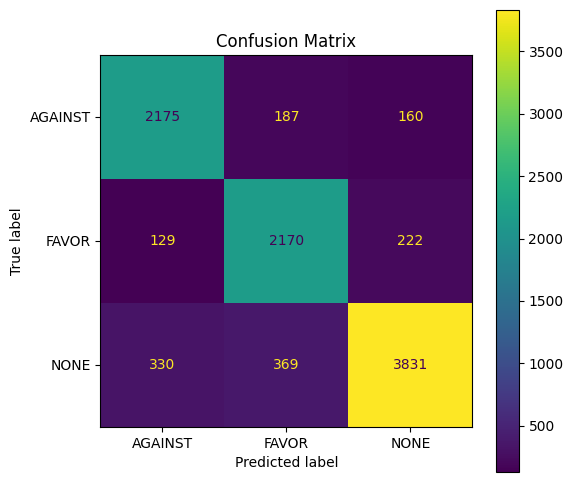

In [ ]:
# Plot Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "AGAINST",
        "FAVOR",
        "NONE"
    ]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax, values_format="d")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Save Best Model
SAVE_DIR = "/content/drive/MyDrive/XLM-R Cross Validation/XLMR_Climate_Final1"

trainer.save_model(SAVE_DIR)

tokenizer.save_pretrained(SAVE_DIR)

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [ ]:
# Part 9- Prediction
# Prediction Function

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# Load Best CV Model
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/XLMR_Climate_Final1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

print("Model Loaded Successfully!")

# ==========================================
# Label Mapping
# ==========================================

label_map = {
    0: "AGAINST",
    1: "FAVOR",
    2: "NONE"
}

# ==========================================
# Prediction Function
# ==========================================

def predict(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model(**inputs)

        pred = torch.argmax(outputs.logits, dim=1).item()

    return label_map[pred]

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/XLM-R Cross Validation/XLMR_Climate_Final1'. Use `repo_type` argument if needed.

In [ ]:
hindi_test = pd.read_excel("/content/Hindi_500_test data.xlsx")

print(hindi_test.head())

hindi_test["Predicted_Label"] = hindi_test["COMMENT"].apply(predict)

hindi_test.to_excel(
    "/content/Hindi_500_Predictions_2.xlsx",
    index=False
)

print("Hindi Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  बिल नाई एक वैज्ञानिक नहीं हैं। वह एक यांत्रिक ...
1   2           ऑनलाइन कक्षाओं के लिए और कौन उपस्थित है?
2   3  शाकाहारियों को इतना परेशान करने वाला क्यों होत...
3   4                      विवरण में बिल न्ये मर्च लिंक।
4   5  बिल के प्रति इतना घृणा क्यों है? मुझे समझ नहीं...
Hindi Prediction Saved Successfully!


In [ ]:
bangla_test = pd.read_excel("/content/Bangla_500_test data.xlsx")

print(bangla_test.head())

bangla_test["Predicted_Label"] = bangla_test["COMMENT"].apply(predict)

bangla_test.to_excel(
    "/content/Bangla_500_Predictions_2.xlsx",
    index=False
)

print("Bangla Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  পৃথিবীর নৃত্য এবং অনন্ত আকাশের মধ্যে, ফিসফিস ক...
1   2  ধন্যবাদ, আপনার করা সমস্ত কিছুর জন্য এবং আপনি য...
2   3  এটি বায়ুমণ্ডলে কার্বন ডাই-অক্সাইডের ২৫০ ডিগ্র...
3   4  জলবায়ু-পরিবর্তক দেবতা-পাথর জানে যে পৃথিবীর দু...
4   5  আমার শিক্ষক আমাকে বলেছিলেন যে প্রতি ১০০ বছরে প...
Bangla Prediction Saved Successfully!


[link text](https://)# Predicting with non weighted model

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# Load Best CV Model
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/Best_XLMR_Climate_Final"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

print("Model Loaded Successfully!")

# ==========================================
# Label Mapping
# ==========================================

label_map = {
    0: "AGAINST",
    1: "FAVOR",
    2: "NONE"
}

# ==========================================
# Prediction Function
# ==========================================

def predict(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model(**inputs)

        pred = torch.argmax(outputs.logits, dim=1).item()

    return label_map[pred]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model Loaded Successfully!


In [ ]:
bangla_test = pd.read_excel("/content/Bangla_500_test data.xlsx")

print(bangla_test.head())

bangla_test["Predicted_Label"] = bangla_test["COMMENT"].apply(predict)

bangla_test.to_excel(
    "/content/Bangla_500_Predictions_3.xlsx",
    index=False
)

print("Bangla Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  পৃথিবীর নৃত্য এবং অনন্ত আকাশের মধ্যে, ফিসফিস ক...
1   2  ধন্যবাদ, আপনার করা সমস্ত কিছুর জন্য এবং আপনি য...
2   3  এটি বায়ুমণ্ডলে কার্বন ডাই-অক্সাইডের ২৫০ ডিগ্র...
3   4  জলবায়ু-পরিবর্তক দেবতা-পাথর জানে যে পৃথিবীর দু...
4   5  আমার শিক্ষক আমাকে বলেছিলেন যে প্রতি ১০০ বছরে প...
Bangla Prediction Saved Successfully!


In [ ]:
hindi_test = pd.read_excel("/content/Hindi_500_test data.xlsx")

print(hindi_test.head())

hindi_test["Predicted_Label"] = hindi_test["COMMENT"].apply(predict)

hindi_test.to_excel(
    "/content/Hindi_500_Predictions_3.xlsx",
    index=False
)

print("Hindi Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  बिल नाई एक वैज्ञानिक नहीं हैं। वह एक यांत्रिक ...
1   2           ऑनलाइन कक्षाओं के लिए और कौन उपस्थित है?
2   3  शाकाहारियों को इतना परेशान करने वाला क्यों होत...
3   4                      विवरण में बिल न्ये मर्च लिंक।
4   5  बिल के प्रति इतना घृणा क्यों है? मुझे समझ नहीं...
Hindi Prediction Saved Successfully!
